In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path
_project_root = str(
    next(
        (
            _p
            for _p in (Path.cwd(), *Path.cwd().parents)
            if (_p / "common.py").is_file()
        ),
        Path.cwd().parent,
    )
)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

import figures_paper.figure_config as figure_config
from common import evaluations_dir

importlib.reload(figure_config)
from figures_paper.figure_config import (
    BARPLOT_REF_LINE_COLORS,
    BARPLOT_REF_LINE_STYLES,
    CONDITION_LABELS,
    FONTSIZE,
    LW_MEDIUM,
    LW_THICK,
    LW_THIN,
    OBS_LABELS,
    REF_DISPLAY_MAP,
    REF_LABELS,
    REF_PALETTE,
    configure_axis_spines,
)


## Configuration

In [2]:
# Style is applied automatically by figure_config on import.
# Re-apply if needed after reload:
# apply_figure_style()

# ── Model ─────────────────────────────────────────────────────────────
data = "dream_cytof"
figure = "figure1a"

models = {
    "DMM": "EGFR_MAPK__logobs",
}

selected_context = "cytof_init"
selected_model = "DMM"



## Load trajectory data

In [3]:
# Load trajectories from all specified models
traj_dfs = []
for label, model_name in models.items():
    path = evaluations_dir / model_name / data / f"trajectories_{figure}.csv"
    if not path.exists():
        print(f"  ⚠ Skipping {label}: {path} not found")
        continue
    df = pd.read_csv(path, index_col=0)
    df["model_label"] = label
    traj_dfs.append(df)
    print(
        f"[{label}] {len(df):,} rows, "
        f"{df['sample'].nunique()} cell lines, "
        f"refs: {sorted(df['ref'].unique())}, "
        f"contexts: {sorted(df['context'].unique())}"
    )

traj = pd.concat(traj_dfs, ignore_index=True)

# Summary
print(f"\nCombined: {len(traj):,} rows")
print(f"  Observables : {sorted(traj['observable'].unique())}")
print(f"  Conditions  : {sorted(traj['condition'].unique())}")
print(f"  Time points : {sorted(traj['time'].unique())}")
print(f"  Cell lines  : {traj['sample'].nunique()}")
print(f"  Datasets    : {sorted(traj['dataset'].unique())}")

# Datapoints per (observable, condition, timepoint, cell-line) combo, by ref
print(f"\nDatapoints per (observable, condition, timepoint, cell-line) combo:")
combo_counts = (
    traj.groupby(["ref"])
    .apply(lambda g: g.groupby(["observable", "condition", "time", "sample"]).size())
    .reset_index(name="n")
)
for ref_name, ref_group in combo_counts.groupby("ref"):
    counts = ref_group["n"]
    print(
        f"  ref={ref_name:15s}: "
        f"{len(ref_group):5d} combos, "
        f"n per combo: min={counts.min()}, median={counts.median():.0f}, max={counts.max()}"
    )

# ── Load per-combo RMSE from by_cl_cond_obs CSV ──────────────────────
by_path = evaluations_dir / models[selected_model] / data / f"by_cl_cond_obs_{figure}.csv"
by_cl = pd.read_csv(by_path, index_col=0).rename(columns={"sample": "cell_line"})

by_dmm_val = by_cl[
    (by_cl["ref"] == "DMM")
    & (by_cl["context"] == selected_context)
    & (by_cl["dataset"] == "val")
]
combo_rmse = by_dmm_val.groupby(["cell_line", "condition", "observable"])["rmse"].median().sort_values()

# ── Select 3 representative combos at RMSE quartiles ──────────────────
quantiles = [0.05, 0.5, 0.95]
q1, q2, q3 = combo_rmse.quantile(quantiles)
combo_q1 = (combo_rmse - q1).abs().idxmin()
combo_q2 = (combo_rmse - q2).abs().idxmin()
combo_q3 = (combo_rmse - q3).abs().idxmin()

HIGHLIGHT_CELL_LINES = [combo_q1[0], combo_q2[0], combo_q3[0]]
print(f"\nRepresentative combos (Q{quantiles[0]*100:.0f} / Q{quantiles[1]*100:.0f} / Q{quantiles[2]*100:.0f} of median per-seed RMSE on val set):")

rep_combos = {}
for quant, combo in zip(quantiles, [combo_q1, combo_q2, combo_q3]):
    cl, cond, obs = combo
    obs_label = OBS_LABELS.get(obs, obs)
    cond_label = CONDITION_LABELS.get(cond, cond)
    cl_display = cl.replace("c", "", 1)
    tag = f"Q{quant*100:.0f}"
    rep_combos[tag] = combo
    print(f"  {tag}  → {cl_display} / {cond_label} / {obs_label}  (RMSE = {combo_rmse[combo]:.4f})")
print(f"  Range: {combo_rmse.min():.4f} – {combo_rmse.max():.4f} ({len(combo_rmse)} combos)")

[DMM] 2,660,256 rows, 63 cell lines, refs: ['DMM', 'avg_model', 'elasticnet', 'lasso', 'linreg', 'sample'], contexts: ['MOSA', 'cytof_init', 'multimodal', 'proteomics', 'transcriptomics']

Combined: 2,660,256 rows
  Observables : ['pERBB2_Y1248_obs', 'pERK_Y204_obs', 'pMEK_S222_obs', 'pRPS6KA1_S380_obs']
  Conditions  : ['EGF', 'iEGFR', 'iMEK']
  Time points : [np.float64(0.0), np.float64(5.5), np.float64(7.0), np.float64(9.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(23.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(60.0)]
  Cell lines  : 63
  Datasets    : ['train', 'val']

Datapoints per (observable, condition, timepoint, cell-line) combo:
  ref=DMM            :  5640 combos, n per combo: min=40, median=300, max=1200
  ref=avg_model      :  5640 combos, n per combo: min=5, median=30, max=120
  ref=elasticnet     :  5655 combos, n per combo: min=4, median=30, max=30
 

## Helper functions

In [4]:
def plot_trajectory(
    traj,
    cell_line,
    condition,
    observable,
    model_label=None,
    context=None,
    refs=None,
    ax=None,
    show_seeds=True,
    title=None,
    rmse_data=None,
):
    """
    Plot a single trajectory: experimental data (obs) + model simulations.

    Parameters
    ----------
    traj : DataFrame
        Full trajectory table.
    cell_line, condition, observable : str
        Which trajectory to plot.
    model_label : str, optional
        Filter to a specific model (e.g. "DMM + tEGFR"). None = first available.
    context : str, optional
        Filter to a specific context (e.g. "cytof_init"). None = first available.
    refs : list of str, optional
        Which reference methods to show. None = all.
    ax : matplotlib Axes, optional
    show_seeds : bool
        If True, show individual random-seed trajectories for DMM.
    title : str, optional
        Custom title. Auto-generated if None.
    rmse_data : dict, optional
        RMSE values by ref name to display as annotations.
    """
    sub = traj[
        (traj["sample"] == cell_line)
        & (traj["condition"] == condition)
        & (traj["observable"] == observable)
    ].copy()

    if model_label is not None:
        sub = sub[sub["model_label"] == model_label]
    else:
        model_label = sub["model_label"].iloc[0] if len(sub) else "?"

    if context is not None:
        sub = sub[sub["context"] == context]
    else:
        context = sub["context"].iloc[0] if len(sub) else "?"

    if refs is not None:
        sub = sub[sub["ref"].isin(refs)]

    if sub.empty:
        print(f"No data for {cell_line} / {condition} / {observable}")
        return ax

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.5))

    # --- Experimental data from obs column (in DMM rows) ---
    if "obs" in sub.columns:
        dmm_obs = sub[sub["ref"] == "DMM"]
        if not dmm_obs.empty and dmm_obs["obs"].notna().any():
            exp_mean = dmm_obs.groupby("time")["obs"].mean()
            ax.plot(
                exp_mean.index, exp_mean.values,
                color=REF_PALETTE.get("obs", "#2ca02c"), marker="o", markersize=3,
                linewidth=LW_THICK, label=REF_LABELS.get("obs", "Experimental"), zorder=10,
            )

    # --- Sample reference (positive control) ---
    sample_ref = sub[sub["ref"] == "sample"]
    if not sample_ref.empty:
        sample_mean = sample_ref.groupby("time")["sim"].mean()
        sample_label = REF_DISPLAY_MAP.get("sample", REF_LABELS.get("sample", "Sample ref"))
        ax.plot(
            sample_mean.index, sample_mean.values,
            color=BARPLOT_REF_LINE_COLORS.get("positive control", REF_PALETTE.get("sample", "#98df8a")),
            linewidth=LW_MEDIUM, linestyle=BARPLOT_REF_LINE_STYLES.get("positive control", "--"),
            alpha=0.7, label=sample_label, zorder=7,
        )

    # --- DMM: individual random-seed trajectories + mean/variance ---
    dmm = sub[sub["ref"] == "DMM"]
    if not dmm.empty:
        # Individual seed trajectories (background)
        if show_seeds:
            seed_cols = [c for c in ["job", "features"] if c in dmm.columns]
            if seed_cols:
                first_seed = True
                for _, seed_df in dmm.groupby(seed_cols):
                    seed_ts = seed_df.sort_values("time")
                    ax.plot(
                        seed_ts["time"], seed_ts["sim"],
                        color=REF_PALETTE["DMM"], alpha=0.12,
                        linewidth=LW_THIN, zorder=3,
                        label=REF_LABELS["DMM"] + " (random seeds)" if first_seed else None,
                    )
                    first_seed = False

        # Mean and variance across seeds (foreground)
        dmm_stats = dmm.groupby("time")["sim"].agg(["mean", "std"]).reset_index()
        ax.fill_between(
            dmm_stats["time"],
            dmm_stats["mean"] - dmm_stats["std"],
            dmm_stats["mean"] + dmm_stats["std"],
            color=REF_PALETTE["DMM"], alpha=0.22, linewidth=0, zorder=4,
            label=REF_LABELS["DMM"] + " (±1 SD)",
        )
        ax.plot(
            dmm_stats["time"], dmm_stats["mean"],
            color=REF_PALETTE["DMM"], linewidth=LW_THICK,
            linestyle="-", label=REF_LABELS["DMM"] + " (mean)", zorder=6,
        )

    # --- Other references (avg_model as negative control, regressors) ---
    for ref_name in ["avg_model", "linreg", "lasso", "elasticnet"]:
        ref_sub = sub[sub["ref"] == ref_name]
        if ref_sub.empty:
            continue
        if refs is not None and ref_name not in refs:
            continue
        ref_mean = ref_sub.groupby("time")["sim"].mean()

        # Apply control styling for avg_model
        if ref_name == "avg_model":
            control_label = REF_DISPLAY_MAP.get("avg_model", REF_LABELS.get("avg_model", "Avg. model"))
            color = BARPLOT_REF_LINE_COLORS.get("negative control", REF_PALETTE.get("avg_model", "grey"))
            linestyle = BARPLOT_REF_LINE_STYLES.get("negative control", "--")
        else:
            control_label = REF_LABELS.get(ref_name, ref_name)
            color = REF_PALETTE.get(ref_name, "grey")
            linestyle = "--"

        ax.plot(
            ref_mean.index, ref_mean.values,
            color=color, linewidth=LW_MEDIUM, linestyle=linestyle,
            label=control_label, zorder=2,
        )

    # --- Labels ---
    obs_label = OBS_LABELS.get(observable, observable)
    cond_label = CONDITION_LABELS.get(condition, condition)
    ax.set_xlabel("Time (min)")
    ax.set_xticks([15, 30, 45, 60])
    ax.set_ylabel(f"{obs_label} [a.u.]")
    if title is None:
        cl_display = cell_line.replace("c", "", 1)
        title = f"{cl_display} — {cond_label}"
    ax.set_title(title)

    # --- Configure axis styling: keep left/bottom spines, show ticks ---
    configure_axis_spines(ax, top=False, right=False, left=True, bottom=True)
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    return ax


## 1. Representative validation trajectories

Three validation-set trajectories selected at the Q10, Q50, and Q90
of the per-combo (cell line × condition × observable) RMSE distribution.
Each panel shows experimental data, DMM mean ± SD, and regression baselines.

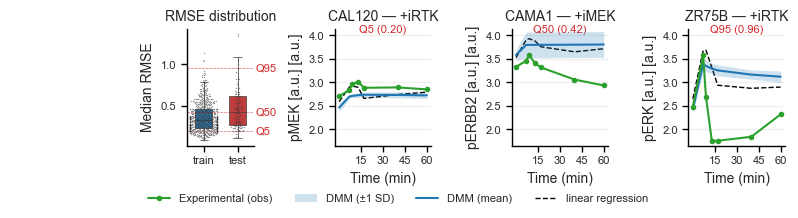

In [5]:
# ── Plot 3 trajectories + empty axis (left) + RMSE distribution (right) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(8, 2), gridspec_kw={"width_ratios": [1.0, 0.7, 1, 1, 1]})
empty_ax = axes[0]
empty_ax.axis("off")
traj_axes = axes[2:6]
dist_ax = axes[1]

for ax, (tag, (cl, cond, obs)) in zip(traj_axes, rep_combos.items()):
    plot_trajectory(
        traj, cl, cond, obs,
        model_label=selected_model,
        context=selected_context,
        refs=["DMM", "elasticnet"],
        ax=ax,
        show_seeds=False,
    )
    obs_label = OBS_LABELS.get(obs, obs)
    cond_label = CONDITION_LABELS.get(cond, cond)
    cl_display = cl.replace("c", "", 1)
    rmse_val = combo_rmse[(cl, cond, obs)]
    ax.set_title(f"{cl_display} — {cond_label}")
    # Colour the quantile tag red, placed above the title
    ax.text(0.5, 0.95, f"{tag} ({rmse_val:.2f})", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=FONTSIZE, color="#d62728")

# ── Consistent y-axis across all trajectory panels ─────────────────────
ymin = min(ax.get_ylim()[0] for ax in traj_axes)
ymax = max(ax.get_ylim()[1] for ax in traj_axes)
for ax in traj_axes:
    ax.set_ylim(ymin, ymax)

# Single legend (trajectory panels)
handles, labels = traj_axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc="lower center", ncol=len(by_label),
    fontsize=FONTSIZE, frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)
for ax in traj_axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

# ── RMSE distribution on the right axis (boxplot + beeswarm) ───────────
dmm_all = by_cl[
    (by_cl["ref"] == "DMM") & (by_cl["context"] == selected_context)
]
combo_rmse_all = (
    dmm_all.groupby(["cell_line", "condition", "observable", "dataset"])["rmse"]
    .median()
    .reset_index()
)
combo_rmse_all.loc[combo_rmse_all["dataset"] == "val","dataset"] = "test" # rename for display
combo_rmse_all["dataset"] = pd.Categorical(combo_rmse_all["dataset"], categories=["train", "test"], ordered=True)
sns.boxplot(
    data=combo_rmse_all,
    x="dataset",
    y="rmse",
    ax=dist_ax,
    palette={"train": "#1f77b4", "test": "#d62728"},
    width=0.5,
    linewidth=LW_THIN,
    flierprops={"marker": "o", "markersize": 0},
)
sns.swarmplot(
    data=combo_rmse_all,
    x="dataset",
    y="rmse",
    order=["train", "test"],
    ax=dist_ax,
    color="#333333",
    size=1,
    alpha=0.5,
)
dist_ax.set_title("RMSE distribution")
dist_ax.set_xlabel("")
dist_ax.set_ylabel("Median RMSE")
configure_axis_spines(dist_ax, top=False, right=False, left=True, bottom=True)
dist_ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
dist_ax.grid(False)

# Mark test quantiles (test dataset)
test_rmse = combo_rmse_all[combo_rmse_all["dataset"] == "test"]["rmse"]
for q, ls in [(0.05, "--"), (0.5, "--"), (0.95, "--")]:
    qv = test_rmse.quantile(q)
    dist_ax.axhline(qv, color="#d62728", linestyle=ls, alpha=0.7, linewidth=LW_THIN)
    dist_ax.text(
        1.02,
        qv,
        f"Q{int(q*100)}",
        transform=dist_ax.get_yaxis_transform(),
        ha="left", va="center", fontsize=FONTSIZE, color="#d62728",
    )

fig.tight_layout()

fig.savefig(str(Path(_project_root) / "figures_paper" / "traj_representative_val.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [6]:
combo_rmse_all.groupby(["dataset"])["rmse"].agg(["min", "median", "max"]).rename(columns={"min": "Min", "median": "Median", "max": "Max"})

,Min,Median,Max
dataset,,,
train,0.088828,0.335811,1.137394
test,0.121284,0.428065,1.359912


In [7]:
# t-test comparing train vs test RMSE distributions
from scipy.stats import ttest_ind
train_rmse = combo_rmse_all[combo_rmse_all["dataset"] == "train"]["rmse"]
test_rmse = combo_rmse_all[combo_rmse_all["dataset"] == "test"]["rmse"]
t_stat, p_value = ttest_ind(train_rmse, test_rmse, equal_var=False)
print(f"\nT-test comparing train vs test RMSE distributions:")
print(f"  t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")


T-test comparing train vs test RMSE distributions:
  t-statistic = -4.1943, p-value = 4.8470e-05


In [8]:
combo_rmse_all["dataset"].unique()

['train', 'test']
Categories (2, object): ['train' < 'test']

## 2. Train vs test RMSE scatter

Scatter of median RMSE across cell lines: x = train, y = test.
Marker shape encodes the observable, colour encodes the condition.
Crosshairs show ± 1 SD across random seeds.
Points above the diagonal indicate a generalisation gap.

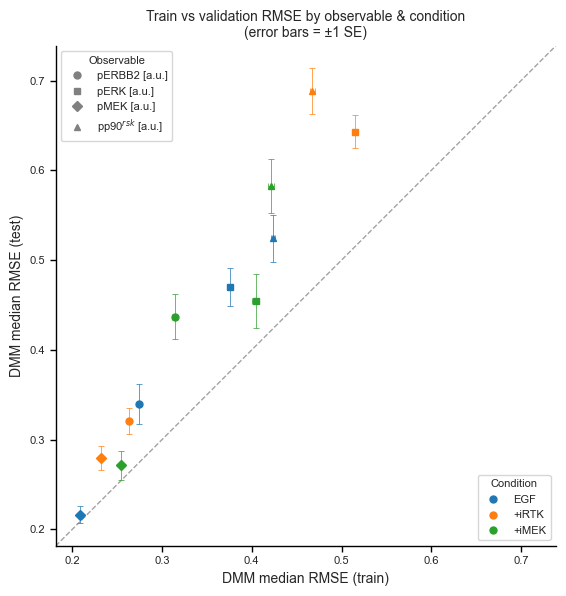

In [9]:
# --- Train vs Test RMSE scatter (DMM only) ---
from matplotlib.lines import Line2D

dmm = by_cl[
    (by_cl["ref"] == "DMM") & (by_cl["context"] == selected_context)
].copy()

# Median and SE of RMSE per (observable, condition, dataset) across cell lines
stats = (
    dmm.groupby(["observable", "condition", "dataset"])["rmse"]
    .agg(["median", "std", "count"])
    .reset_index()
)
stats["se"] = stats["std"] / np.sqrt(stats["count"])

train_stats = stats[stats["dataset"] == "train"].rename(
    columns={"median": "median_train", "se": "se_train"}
).drop(columns=["dataset", "std", "count"])
val_stats = stats[stats["dataset"] == "val"].rename(
    columns={"median": "median_val", "se": "se_val"}
).drop(columns=["dataset", "std", "count"])

scatter_df = train_stats.merge(val_stats, on=["observable", "condition"])

# Marker shapes per observable
obs_markers = {
    "pERBB2_Y1248_obs": "o",
    "pERK_Y204_obs": "s",
    "pMEK_S222_obs": "D",
    "pRPS6KA1_S380_obs": "^",
}

# Condition colours
cond_colors = {
    "EGF": "#1f77b4",
    "iEGFR": "#ff7f0e",
    "iMEK": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in scatter_df.iterrows():
    obs = row["observable"]
    cond = row["condition"]
    x, y = row["median_train"], row["median_val"]
    xerr, yerr = row["se_train"], row["se_val"]
    ax.errorbar(
        x, y, xerr=xerr, yerr=yerr,
        fmt=obs_markers.get(obs, "o"),
        color=cond_colors.get(cond, "grey"),
        markersize=5, capsize=2, capthick=LW_THIN, elinewidth=LW_THIN,
        zorder=3,
    )

# Diagonal reference line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, "k--", alpha=0.4, lw=LW_MEDIUM, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("DMM median RMSE (train)")
ax.set_ylabel("DMM median RMSE (test)")
ax.set_title("Train vs validation RMSE by observable & condition\n(error bars = ±1 SE)")
ax.set_aspect("equal")

# Build legends
obs_handles = [
    Line2D([], [], marker=m, color="grey", linestyle="", markersize=5,
           label=OBS_LABELS.get(o, o))
    for o, m in obs_markers.items()
]
cond_handles = [
    Line2D([], [], marker="o", color=c, linestyle="", markersize=5,
           label=CONDITION_LABELS.get(c_key, c_key))
    for c_key, c in cond_colors.items()
]

leg1 = ax.legend(handles=obs_handles, title="Observable", loc="upper left",
                 fontsize=FONTSIZE, title_fontsize=FONTSIZE)
ax.add_artist(leg1)
configure_axis_spines(ax, top=False, right=False, left=True, bottom=True)
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax.grid(False)
ax.legend(handles=cond_handles, title="Condition", loc="lower right",
          fontsize=FONTSIZE, title_fontsize=FONTSIZE)

plt.tight_layout()
plt.show()

In [10]:

# ── Unpaired test: train RMSE ≠ test RMSE per (obs, cond) combo ──────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

dmm_test = by_cl[
    (by_cl["ref"] == "DMM") & (by_cl["context"] == selected_context)
].copy()

# Per cell-line median RMSE (across seeds) for each (obs, cond, dataset)
cl_rmse = (
    dmm_test.groupby(["observable", "condition", "dataset", "cell_line"])["rmse"]
    .median()
    .reset_index()
)

results = []
for (obs, cond), grp in cl_rmse.groupby(["observable", "condition"]):
    train = grp.loc[grp["dataset"] == "train", "rmse"].values
    val   = grp.loc[grp["dataset"] == "val",   "rmse"].values
    u_stat, p_val = mannwhitneyu(val, train, alternative="greater")
    results.append({
        "observable": OBS_LABELS.get(obs, obs),
        "condition":  CONDITION_LABELS.get(cond, cond),
        "n_train": len(train),
        "n_val":   len(val),
        "median_train": np.median(train),
        "median_val":   np.median(val),
        "U": u_stat,
        "p_raw": p_val,
    })

results_df = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
reject, p_adj, _, _ = multipletests(results_df["p_raw"], method="fdr_bh")
results_df["p_adj"] = p_adj
results_df["significant"] = reject

# Display
print("Mann–Whitney U test per (observable, condition) — H₁: val RMSE > train RMSE")
print("Multiple-testing correction: Benjamini–Hochberg FDR\n")
for _, r in results_df.iterrows():
    sig = "✓" if r["significant"] else "✗"
    print(
        f"  {r['observable']:8s} / {r['condition']:14s}  "
        f"n=({r['n_train']},{r['n_val']})  "
        f"med train={r['median_train']:.4f}  med val={r['median_val']:.4f}  "
        f"U={r['U']:.0f}  p_raw={r['p_raw']:.4g}  p_adj={r['p_adj']:.4g}  {sig}"
    )

n_sig = results_df["significant"].sum()


Mann–Whitney U test per (observable, condition) — H₁: val RMSE > train RMSE
Multiple-testing correction: Benjamini–Hochberg FDR

  pERBB2 [a.u.] / EGF             n=(44,10)  med train=0.2702  med val=0.3137  U=296  p_raw=0.04636  p_adj=0.09272  ✗
  pERBB2 [a.u.] / +iRTK           n=(44,10)  med train=0.2525  med val=0.3068  U=296  p_raw=0.04636  p_adj=0.09272  ✗
  pERBB2 [a.u.] / +iMEK           n=(41,10)  med train=0.3207  med val=0.4342  U=309  p_raw=0.007035  p_adj=0.03619  ✓
  pERK [a.u.] / EGF             n=(58,10)  med train=0.3668  med val=0.4670  U=351  p_raw=0.1474  p_adj=0.1965  ✗
  pERK [a.u.] / +iRTK           n=(58,10)  med train=0.5117  med val=0.6552  U=427  p_raw=0.009048  p_adj=0.03619  ✓
  pERK [a.u.] / +iMEK           n=(58,10)  med train=0.4091  med val=0.4733  U=346  p_raw=0.1683  p_adj=0.2019  ✗
  pMEK [a.u.] / EGF             n=(58,10)  med train=0.2172  med val=0.2111  U=310  p_raw=0.3678  p_adj=0.3678  ✗
  pMEK [a.u.] / +iRTK           n=(58,10)  med train=0.23

In [11]:
display(results_df)

,observable,condition,n_train,n_val,median_train,median_val,U,p_raw,p_adj,significant
0,pERBB2 [a.u.],EGF,44,10,0.270197,0.313734,296.0,0.046358,0.092716,False
1,pERBB2 [a.u.],+iRTK,44,10,0.252459,0.306820,296.0,0.046358,0.092716,False
2,pERBB2 [a.u.],+iMEK,41,10,0.320722,0.434224,309.0,0.007035,0.036191,True
3,pERK [a.u.],EGF,58,10,0.366820,0.467038,351.0,0.147405,0.196540,False
4,pERK [a.u.],+iRTK,58,10,0.511660,0.655239,427.0,0.009048,0.036191,True
5,pERK [a.u.],+iMEK,58,10,0.409056,0.473342,346.0,0.168264,0.201917,False
6,pMEK [a.u.],EGF,58,10,0.217226,0.211057,310.0,0.367808,0.367808,False
7,pMEK [a.u.],+iRTK,58,10,0.236221,0.282615,357.0,0.124758,0.187137,False
8,pMEK [a.u.],+iMEK,58,10,0.250696,0.270041,324.0,0.280926,0.306465,False
9,pp90$^{rsk}$ [a.u.],EGF,58,10,0.431617,0.516904,372.0,0.079083,0.135570,False
